# Code for making diagrams and organsing results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from ast import literal_eval
import csv
from sklearn import metrics

Best Algorithm, Train, Test
BothFiltered (Elgendi) + PCA 60 + GSVM ({'C': 10, 'gamma': 0.01}): 0.9862936861786279, 0.8503381642512077
SMOTE (minority) + PCA 75 + LSVM ({'C': 0.05}): 0.9065708660700743, 0.8371980676328501
SMOTE (not minority) + PCA 65 + GSVM ({'C': 10, 'gamma': 0.001}): 0.9063437270779777, 0.8458454106280193
SMOTE (not minority)+BothFiltered (Elgendi) + PCA 45 + GSVM ({'C': 10, 'gamma': 0.005}): 0.968784172265414, 0.846135265700483
NoFilter NoSMOTE + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179


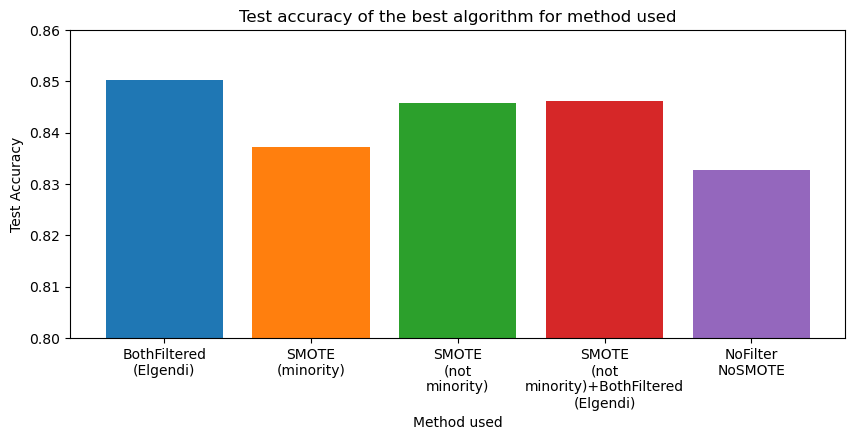

In [4]:
algors=['KNN','NLSVM','GSVM','LSVM','GDT','EDT','XGB']
folders='Results/Best'
resultfolder=os.listdir(folders)
if '.DS_Store' in resultfolder: resultfolder.remove('.DS_Store')
plt.figure(figsize=(10, 4))
plt.title(f"Test accuracy of the best algorithm for method used")
print("Best Algorithm, Train, Test")
hw=[]
for x in range(0,len(resultfolder)):
  best=[]
  algor=[]
  PCAval=[]
  trainacc=[]
  for y in range(10,85,5):
    csvfolder = pd.read_csv(f"{folders}/{resultfolder[x]}/ALL{y}.csv")
    algorlist=[literal_eval(x) for x in list(csvfolder['Test_Accuracy'])]
    algorlist=[np.mean(x) for x in algorlist]
    best.append(max(algorlist))
    algor.append(csvfolder['Algorithm'][algorlist.index(max(algorlist))])
    PCAval.append(y)
    trainacc.append(csvfolder['Train_Accuracy'][algorlist.index(max(algorlist))])
  print(f"{resultfolder[x]} + PCA {PCAval[best.index(max(best))]} + {algor[best.index(max(best))]}",end=" ")
  print(f"{np.mean(literal_eval(trainacc[best.index(max(best))]))}, {max(best)}")
  hw.append(
    [resultfolder[x],PCAval[best.index(max(best))],
     algor[best.index(max(best))].split(' ')[0],
     algor[best.index(max(best))].replace(f"{algor[best.index(max(best))].split(' ')[0]} ",''),
   round(np.mean(literal_eval(trainacc[best.index(max(best))])),3),
   round(max(best),3),
   round(round(max(best),3)-round(np.mean(literal_eval(trainacc[best.index(max(best))])),3),3)])
  plt.bar(str(resultfolder[x]).replace(' ','\n'),max(best))

best=[]
algor=[]
PCAval=[]
trainacc=[]
for y in range(10,85,5):
    csvfolder = pd.read_csv(f"Results/NoFilter NoSMOTE/ALL{y}.csv")
    algorlist=[literal_eval(x) for x in list(csvfolder['Test_Accuracy'])]
    algorlist=[np.mean(x) for x in algorlist]
    best.append(max(algorlist))
    algor.append(csvfolder['Algorithm'][algorlist.index(max(algorlist))])
    PCAval.append(y)
    trainacc.append(csvfolder['Train_Accuracy'][algorlist.index(max(algorlist))])
print(f"NoFilter NoSMOTE + PCA {PCAval[best.index(max(best))]} + {algor[best.index(max(best))]}",end=" ")
print(f"{np.mean(literal_eval(trainacc[best.index(max(best))]))}, {max(best)}")
plt.bar("NoFilter\nNoSMOTE",max(best))
hw.append(
  ['NoFilter NoSMOTE',PCAval[best.index(max(best))],
   algor[best.index(max(best))].split(' ')[0],algor[best.index(max(best))].replace(f"{algor[best.index(max(best))].split(' ')[0]} ",
   ''),
   round(np.mean(literal_eval(trainacc[best.index(max(best))])),3),
   round(max(best),3),
   round(round(max(best),3)-round(np.mean(literal_eval(trainacc[best.index(max(best))])),3),3)])

plt.ylabel("Test Accuracy")
plt.xlabel("Method used")
plt.ylim([0.8,0.86])
plt.show()

file = open(f'Table/Summary.csv', 'w', newline ='')
with file:
  write = csv.writer(file)
  write.writerow(['Scenario','PCA','Algorithm','Hyperparameters','Train Accuracy (mean)','Test Accuracy (mean)','Test - Train'])
  for x in hw:
    write.writerow(x)

In [ ]:
def get_graph(result, algorithm, pca, params,graph):
  value=params

  csv = pd.read_csv(f"New Results/{result}/{algorithm}/{pca}_{value}.csv")
  c_val=csv[f'{value} value']
  acc=[literal_eval(x) for x in csv['Test_Accuracy']]
  acc=[np.mean(x) for x in acc]
  c_val=[str(x) for x in c_val]
  plt.figure(figsize=(9, 4))
  if graph=='plot':
    plt.plot(c_val, acc, marker='o')
  else:
    plt.bar(c_val, acc)
  plt.title(f'Effect of hyperparameter {value}')
  plt.xlabel(f'Value of {value}')
  plt.ylabel('Test accuracy')
  plt.show()
def get_pca_chart(result, algorithm):
  best=[]
  plt.figure(figsize=(6, 2))
  plt.title(f"{result} {algorithm} accuracy using PCA")
  for y in range(10,90,5):
    csv = pd.read_csv(f"New Results/{result}/ALL{y}.csv")
    acc=[literal_eval(x) for x in csv['Test_Accuracy']]
    acc=[np.mean(x) for x in acc]
    for x in list(csv['Algorithm']):
      if algorithm == x.split(' ({')[0]:
        indexnum=list(csv['Algorithm']).index(x)
        break
    best.append(acc[indexnum])
  plt.plot(range(10,90,5),best, marker='o')
  plt.ylabel(f"Test Accuracy")
  plt.xlabel("n_components")
  plt.ylim([min(best)-0.01,max(best)+0.01])
  plt.show()
def get_cf(folders,algorithm,PCAbest):
  csvfolder = pd.read_csv(f"New Results/{folders}/ALL{PCAbest}.csv")
  for x in list(csvfolder['Algorithm']):
    if algorithm == x.split(' ({')[0]:
      indexnum=list(csvfolder['Algorithm']).index(x)
      break
  try:
    cf=csvfolder['Confusion_Matrix'][indexnum]
  except KeyError:
    cf=csvfolder['Test_Confusion_Matrix'][indexnum]
  cf=cf.replace('array','')
  cf=literal_eval(cf)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = np.mean(cf, axis=0), display_labels = ['Aerobic', 'Anerobic', 'Rest', 'Stress'])

  cm_display.plot()
  plt.show() 
def save_to_details(folders,algorithm,PCAbest):
  setting=['micro','macro','weighted']
  csvfolder = pd.read_csv(f"New Results/{folders}/ALL{PCAbest}.csv")
  for x in list(csvfolder['Algorithm']):
    if algorithm == x.split(' ({')[0]:
      print(x.split(' ({')[0])
      indexnum=list(csvfolder['Algorithm']).index(x)
      break
  file = open(f'Table/Details.csv', 'w', newline ='')
  with file:
    write = csv.writer(file)
    write.writerow([' ','Train Precision','Train recall','Train F1','Test Precision','Test recall','Test F1'])
    for x in setting:
      write.writerow([x,
                      round(np.mean(literal_eval(csvfolder[f'Train_Precision_{x}'][indexnum])),3),
                      round(np.mean(literal_eval(csvfolder[f'Train_Recall_{x}'][indexnum])),3),
                      round(np.mean(literal_eval(csvfolder[f'Train_f1_{x}'][indexnum])),3),
                      round(np.mean(literal_eval(csvfolder[f'Test_Precision_{x}'][indexnum])),3),
                      round(np.mean(literal_eval(csvfolder[f'Test_Recall_{x}'][indexnum])),3),
                      round(np.mean(literal_eval(csvfolder[f'Test_f1_{x}'][indexnum])),3)])

Best Algorithm, Train, Test
SMOTE (minority) + PCA 75 + LSVM ({'C': 0.05}): 0.9065708660700743, 0.8371980676328501
RandomOverSampler (minority) + PCA 55 + GSVM ({'C': 10, 'gamma': 0.005}): 0.9663835369824341, 0.8347342995169083
BorderlineSMOTE (minority) + PCA 80 + GSVM ({'C': 10, 'gamma': 0.005}): 0.9672578549666294, 0.8324637681159419
ADASYN (minority) + PCA 80 + GSVM ({'C': 5, 'gamma': 'scale'}): 0.9781536201246116, 0.8303381642512078
NoFilter NoSMOTE + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179

Cheby2_rs40 + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179
EDAFiltered + PCA 75 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9353894002588812, 0.8392753623188405
BothFiltered (Elgendi) + PCA 60 + GSVM ({'C': 10, 'gamma': 0.01}): 0.9862936861786279, 0.8503381642512077
BVPFiltered (Elgendi) + PCA 55 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9481159211850999, 0.8461352657004829
Cheby2_rs20 + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179
Cheby2_rs60 + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179
NoFilter NoSMOTE + PCA 80 + GSVM ({'C': 5, 'gamma': 0.005}): 0.9361222973296897, 0.8326570048309179

Best Algorithm, Train, Test
SMOTE (minority) + PCA 75 + LSVM ({'C': 0.05}): 0.9065708660700743, 0.8371980676328501
SMOTE (all) + PCA 40 + GSVM ({'C': 5, 'gamma': 0.01}): 0.9750193477059149, 0.8371497584541062
SMOTE (not minority) + PCA 65 + GSVM ({'C': 10, 'gamma': 0.001}): 0.9063437270779777, 0.8458454106280193
SMOTE (not majority) + PCA 60 + LSVM ({'C': 0.05}): 0.9170356550580431, 0.834927536231884

SMOTE (not minority)+BothFiltered (Elgendi) + PCA 45 + GSVM ({'C': 10, 'gamma': 0.005}): 0.968784172265414, 0.846135265700483

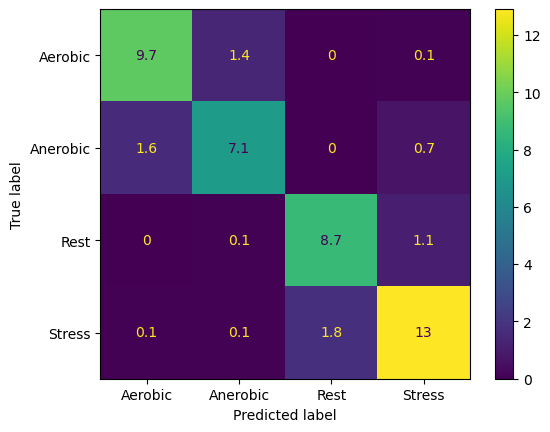

GSVM


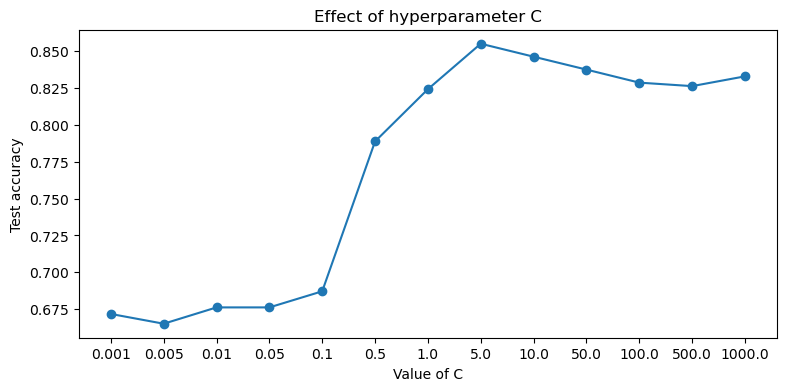

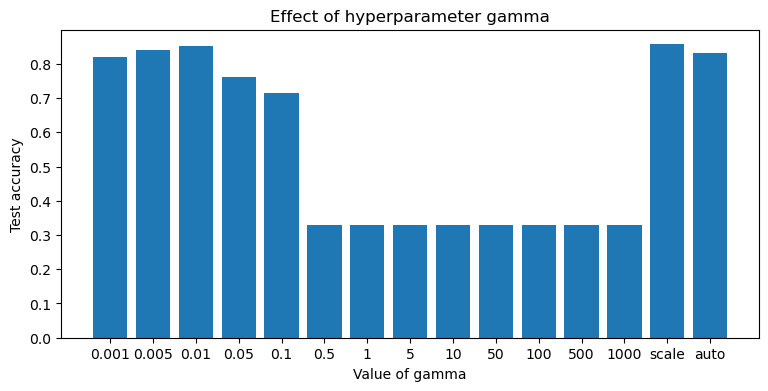

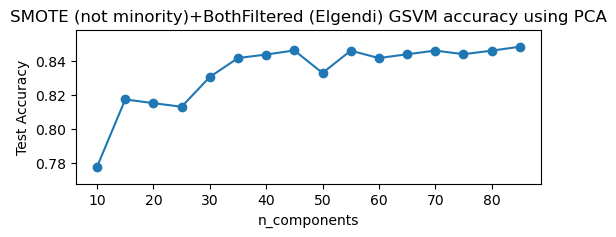

In [34]:
pastehere='SMOTE (not minority)+BothFiltered (Elgendi) + PCA 45 + GSVM'

folder=pastehere.split(' + ')[0]
pcabest=pastehere.split(' + ')[1].replace('PCA ','')
algorbest=pastehere.split(' + ')[2]

get_cf(folder,algorbest,pcabest)
save_to_details(folder,algorbest,pcabest)
get_graph(folder,algorbest,pcabest,'C','plot')
get_graph(folder,algorbest,pcabest,'gamma','bar')
get_pca_chart(folder,algorbest)

In [27]:
x=literal_eval("[('TEMP_max_ratio', -0.3774743993169743), ('HRV_MedianNN', 0.3313945037343098), ('SCR_Height_Mean', 0.3300756988070416), ('SCR_Amplitude_std', -0.3211226343965991), ('HRV_Prc20NN', -0.24682569943847832), ('TEMP_std', 0.21311646749662735), ('SCR_Amplitude_Mean', -0.2027986447241513), ('x_min', 0.1842594733460185), ('TEMP_min_ratio', -0.1770849066212043), ('SCR_Height_std', 0.15734169496084627), ('HRV_MCVNN', -0.15591679342186332), ('HRV_LnHF', 0.13367665649100238), ('z_std', 0.13356542717758435), ('z_min', -0.13145066082834314), ('HRV_Prc80NN', -0.12760558696490976), ('HRV_pNN20', -0.11170858840721795), ('x_max', -0.10960127469402713), ('EDA_Tonic_min_ratio', 0.1086534894882509), ('HRV_pNN50', 0.10662354999669042), ('x_min_ratio', -0.10640037833410032), ('ACC_min_ratio', 0.10287937584079052), ('z_mean', 0.10085627435332384), ('x_std', -0.09649241574133773), ('HRV_SDNNI2', 0.08704527544599254), ('HRV_SDANN2', 0.08436728491116799), ('HRV_SDANN5', -0.08058827543298212), ('HR_max_ratio', 0.08006464500630359), ('HRV_SDNNI5', 0.07919934090847044), ('HRV_HFn', -0.07526029564141352), ('SCR_RecoveryTime_std', 0.06895922965563964), ('HRV_IQRNN', 0.06805400637533926), ('ACC_max', -0.06646369661424714), ('z_min_ratio', -0.06118375196099378), ('HRV_VLF', -0.06105684646176185), ('HRV_SDANN1', -0.060085491643801434), ('SCR_RecoveryTime_Mean', -0.060060652830808824), ('y_std', 0.05482575425303102), ('x_mean', -0.053023522018322465), ('z_max_ratio', 0.052674704083714025), ('EDA_Phasic_Mean', -0.05010153497317184), ('y_min_ratio', 0.049754243986136565), ('HR_std', -0.047876578154604825), ('SCR_RiseTime_std', 0.04718510946735281), ('HRV_MadNN', 0.045872622377761574), ('TEMP_min', -0.04405759418535221), ('EDA_Phasic_std', 0.04172525674511077), ('HRV_SDNNI1', -0.0407927620134631), ('HRV_LFn', 0.039272753640961416), ('HRV_VHF', -0.03798730700131721), ('Peaks_density', -0.036559976709473814), ('HRV_LFHF', 0.035492012339117474), ('bvp_max_ratio', 0.035316527349411944), ('TEMP_max', 0.03442775877336748), ('bvp_max', 0.03382685157041507), ('EDA_Tonic_std', -0.03267856976516435), ('x_max_ratio', 0.030772790521381287), ('z_max', 0.030158839292876452), ('HRV_TP', -0.030038856975603864), ('ibi_mean', -0.02642563806522734), ('HRV_MeanNN', -0.02642563806522672), ('y_max_ratio', -0.024994171756771526), ('HR_max', -0.022519849979756597), ('ACC_min', -0.022447469271294894), ('HRV_CVNN', 0.02184741361606904), ('bvp_std', -0.019974103516321718), ('bvp_min_ratio', 0.019945299276152857), ('EDA_std', -0.019858838037505627), ('HRV_MinNN', 0.0192522292548596), ('ibi_min', 0.019252229254857717), ('HR_min', 0.018523563210965786), ('HR_mean', -0.017335585351482313), ('y_min', 0.016516231515803927), ('HRV_HTI', 0.01573199961963208), ('HRV_TINN', 0.01573199961963201), ('ACC_max_ratio', -0.015170255804234572), ('HRV_SDSD', -0.015077713071466624), ('HRV_RMSSD', -0.013816316181547831), ('y_max', -0.013508529099752448), ('HRV_LF', -0.013325905140818769), ('EDA_Tonic_Mean', 0.013031818791747377), ('EDA_Mean', 0.012453657303926398), ('SCR_RiseTime_Mean', 0.010353407977663334), ('bvp_mean', -0.009944825311593446), ('ACC_mean', -0.009417839503496853), ('y_mean', 0.009327385538050972), ('HRV_MaxNN', 0.009031622592794213), ('ibi_max', 0.009031622592793179), ('bvp_min', 0.0079933110197771), ('HR_min_ratio', 0.00747305184375625), ('HRV_SDNN', 0.0036471452057722925), ('ACC_std', -0.003439015576491263), ('HRV_SDRMSSD', -0.0023242819677428764), ('EDA_Tonic_max_ratio', 0.0020613351484896313), ('HRV_CVSD', -0.0014033744842076364), ('HRV_HF', -0.0008045621052150814), ('TEMP_mean', -1.894489056483012e-05)]")
for i in range(0,60):
  if 'x_' in x[i][0]:
    print(x[i][0], end=", ")

TEMP_max_ratio, x_min, x_max, x_min_ratio, x_std, HR_max_ratio, x_mean, z_max_ratio, bvp_max_ratio, x_max_ratio, 

'bvp_mean', 'bvp_std', 'bvp_max', 'bvp_min', 'bvp_max_ratio', 'bvp_min_ratio', 
'HR_mean',  'HR_std', 'HR_max', 'HR_min', 'HR_max_ratio', 'HR_min_ratio', 
'ibi_mean', 'ibi_max', 'ibi_min', 'HRV_pNN20', 'HRV_pNN50', 'HRV_RMSSD', 'HRV_MeanNN', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 
'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 
'EDA_Mean', 'EDA_std', 'EDA_Tonic_Mean', 'EDA_Phasic_Mean', 'EDA_Tonic_std', 'EDA_Phasic_std', 'EDA_Tonic_max_ratio', 'EDA_Tonic_min_ratio', 'SCR_Amplitude_Mean', 'SCR_Height_Mean', 'SCR_RiseTime_Mean', 'SCR_RecoveryTime_Mean', 'SCR_Amplitude_std', 'SCR_Height_std', 'SCR_RiseTime_std', 'SCR_RecoveryTime_std', 
'ACC_mean', 'ACC_std', 'ACC_max_ratio', 'ACC_min_ratio', 'x_mean', 'y_mean', 'z_mean', 'x_std', 'y_std', 'z_std', 'x_max_ratio', 'y_max_ratio', 'z_max_ratio', 'x_min_ratio', 'y_min_ratio', 'z_min_ratio', 
'TEMP_mean', 'TEMP_std', 'TEMP_max', 'TEMP_min', 'TEMP_max_ratio', 'TEMP_min_ratio'

ACC_min_ratio, ACC_max,
x_min, x_max, x_mean, x_min_ratio, x_std, x_max_ratio,
y_std, y_min_ratio,
z_std, z_min, z_mean, z_min_ratio, z_max_ratio, z_max,

In [39]:
# print(len(['ACC_mean','ACC_std','ACC_max_ratio','ACC_min_ratio','ACC_max','ACC_min','x_mean','y_mean','z_mean','x_std','y_std','z_std','x_max_ratio','y_max_ratio','z_max_ratio','x_min_ratio','y_min_ratio','z_min_ratio','x_max','y_max','z_max','x_min','y_min','z_min']))
x=['TEMP_mean','TEMP_std','TEMP_max','TEMP_min','TEMP_max_ratio','TEMP_min_ratio']
for y in x:
  print(y, end=", ")

TEMP_mean, TEMP_std, TEMP_max, TEMP_min, TEMP_max_ratio, TEMP_min_ratio, 